In [1]:
import numpy as np
from scipy.stats import beta

import pymc as pm

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
prior_a = 1.
prior_b = 1.

# observed data
k = 3  # number of tea drinkers
n = 5  # number of people surveyed

# posterior
post_a = prior_a + k
post_b = prior_b + (n - k)

post_a, post_b

(4.0, 3.0)

In [3]:
with pm.Model() as model:
    p = pm.Beta("p", alpha=prior_a, beta=prior_b)
    likelihood = pm.Binomial("k", n=n, p=p, observed=k)

    post_samples = pm.sample(draws=10_000, chains=1, random_seed=0)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [p]


/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 1_000 tune and 10_000 draw iterations (1_000 + 10_000 draws total) took 1 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [4]:
post_samples = post_samples["posterior"].p.data.flatten()
np.save("./p_post_samples.npy", post_samples)

In [3]:
post_samples = np.load("./p_post_samples.npy")

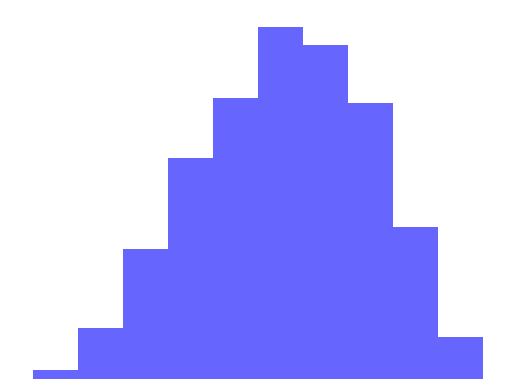

In [10]:
plt.hist(
    post_samples,
    color="b", 
    density=True, 
    alpha=0.6, 
    label="Histogram of samples",
)

# xs = np.linspace(0, 1, 101)
# plt.plot(xs, beta.pdf(xs, post_a, post_b), c="k", linewidth=5, label="True PDF")

# plt.legend()

plt.axis("off")

plt.show()

In [7]:
beta.mean(post_a, post_b), post_samples.mean()

(np.float64(0.5714285714285714), np.float64(0.571210248354677))

In [8]:
(
    beta.interval(0.95, post_a, post_b),
    (np.quantile(post_samples, 0.025), np.quantile(post_samples, 0.975))
)

((np.float64(0.22277809550351216), np.float64(0.8818827512429748)),
 (np.float64(0.22158639775790265), np.float64(0.8835046536157563)))

In [9]:
(
    beta.cdf(0.7, post_a, post_b),
    (post_samples < 0.7).mean(),
)

(np.float64(0.7443099999999999), np.float64(0.7397))

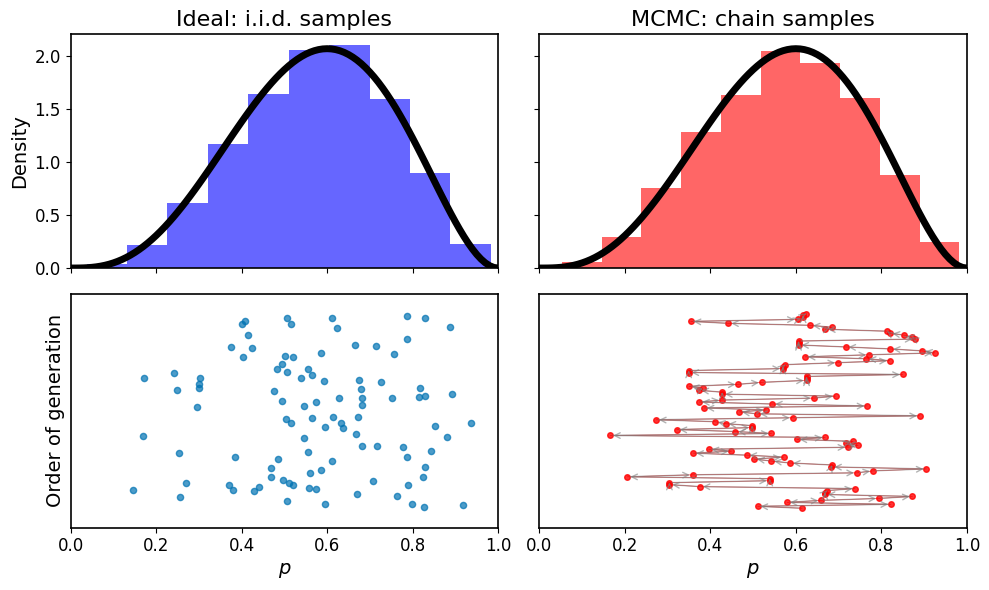

In [38]:
iid_samples = beta.rvs(post_a, post_b, size=10_000, random_state=0)
# iid_samples = np.sort(iid_samples)
post_samples = np.load("./p_post_samples.npy")

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey="row", sharex=True)

## ---- Panel 1: i.i.d. samples ----
ax = axes[0, 0]
ax.set_title("Ideal: i.i.d. samples")
ax.hist(iid_samples, color="b", alpha=0.6, density=True)
xs = np.linspace(0, 1, 101)
ax.plot(xs, beta.pdf(xs, post_a, post_b), c="k", linewidth=5)

iid_samples = iid_samples[-100:]

ax = axes[1, 0]
np.random.seed(0)
y = np.random.uniform(0, 1, size=len(iid_samples))  # jitter vertically
ax.scatter(iid_samples, y, alpha=0.7, s=20)
# ax.scatter(iid_samples, np.linspace(0, 1, len(iid_samples)), alpha=0.7, s=20)
# ax.set_xlim(min(iid_samples.min(), post_samples.min()), max(iid_samples.max(), post_samples.max()))
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([])
ax.set_xlabel(r"$p$")
ax.set_ylabel("")

## ---- Panel 2: MCMC samples (chain) ----
ax = axes[0, 1]
ax.set_title("MCMC: chain samples")
ax.hist(post_samples, color="r", alpha=0.6, density=True)
ax.plot(xs, beta.pdf(xs, post_a, post_b), c="k", linewidth=5)

post_samples = post_samples[-min(len(post_samples), 100):]  # limit length for visibility

ax = axes[1, 1]
y_chain = np.linspace(0, 1, len(post_samples))  # increasing time
ax.plot(post_samples, y_chain, '-o', markersize=4, alpha=0.8, lw=0.5, color="r")
# ax.set_xlim(min(iid_samples.min(), post_samples.min()), max(iid_samples.max(), post_samples.max()))
ax.set_xlim(0, 1)
ax.set_xlabel(r"$p$")
ax.set_yticks([])
ax.set_ylabel("")

# Optional: draw arrows to emphasize direction
for i in range(len(post_samples) - 1):
    ax.annotate(
        '', 
        xy=(post_samples[i+1], y_chain[i+1]), 
        xytext=(post_samples[i], y_chain[i]),
        arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.6)
    )

axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Order of generation")

plt.tight_layout()
plt.show()

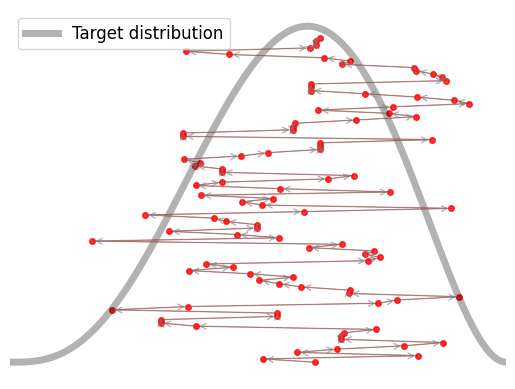

In [6]:
post_samples = post_samples[-min(len(post_samples), 100):]  # limit length for visibility

y_chain = np.linspace(0, 1, len(post_samples))  # increasing time
plt.plot(post_samples, y_chain, '-o', markersize=4, alpha=0.8, lw=0.5, color="r")

for i in range(len(post_samples) - 1):
    plt.annotate(
        '', 
        xy=(post_samples[i+1], y_chain[i+1]), 
        xytext=(post_samples[i], y_chain[i]),
        arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.6)
    )

xs = np.linspace(0, 1, 101)
plt.plot(xs, beta.pdf(xs, post_a, post_b) / 2, alpha=0.3, c="k", linewidth=5, label="Target distribution")

plt.xlim(0, 1)
plt.legend()
plt.axis("off")
plt.show()